In [4]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

from xgboost import XGBClassifier

# Project root
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import TRAIN_A, TRAIN_B, RESULTS_DIR, MODELS_DIR

print("Training Set A:", TRAIN_A)
print("Training Set B:", TRAIN_B)
print("Results:", RESULTS_DIR)
print("Models:", MODELS_DIR)

Training Set A: C:\TwinSepsis\dataset\physionet.org\files\challenge-2019\1.0.0\training\training_setA
Training Set B: C:\TwinSepsis\dataset\physionet.org\files\challenge-2019\1.0.0\training\training_setB
Results: C:\TwinSepsis\results
Models: C:\TwinSepsis\models


In [5]:
train_ids = pd.read_csv(RESULTS_DIR / "train_patient_ids.csv")["patient_id"].tolist()
val_ids = pd.read_csv(RESULTS_DIR / "val_patient_ids.csv")["patient_id"].tolist()
test_ids = pd.read_csv(RESULTS_DIR / "test_patient_ids.csv")["patient_id"].tolist()

print("Training patients:", len(train_ids))
print("Validation patients:", len(val_ids))
print("Test patients:", len(test_ids))

Training patients: 28235
Validation patients: 6050
Test patients: 6051


In [6]:
all_patient_files = {}

for file_path in TRAIN_A.glob("*.psv"):
    all_patient_files[file_path.stem] = file_path

for file_path in TRAIN_B.glob("*.psv"):
    all_patient_files[file_path.stem] = file_path

print("Total patient files found:", len(all_patient_files))

missing_train = [pid for pid in train_ids if pid not in all_patient_files]
missing_val = [pid for pid in val_ids if pid not in all_patient_files]
missing_test = [pid for pid in test_ids if pid not in all_patient_files]

print("Missing training patients:", len(missing_train))
print("Missing validation patients:", len(missing_val))
print("Missing test patients:", len(missing_test))

Total patient files found: 40336
Missing training patients: 0
Missing validation patients: 0
Missing test patients: 0


In [7]:
FEATURE_COLUMNS = None

def load_patients(patient_ids, split_name):
    frames = []

    for i, pid in enumerate(patient_ids):
        file_path = all_patient_files[pid]

        df = pd.read_csv(file_path, sep="|")

        # Remove target from features later; keep it here for now
        df["patient_id"] = pid

        frames.append(df)

        if (i + 1) % 2000 == 0:
            print(f"{split_name}: loaded {i + 1:,} / {len(patient_ids):,} patients")

    data = pd.concat(frames, ignore_index=True)

    print(f"\n{split_name} complete")
    print("Rows:", f"{len(data):,}")
    print("Columns:", len(data.columns))

    return data


train_df = load_patients(train_ids, "Training")

Training: loaded 2,000 / 28,235 patients
Training: loaded 4,000 / 28,235 patients
Training: loaded 6,000 / 28,235 patients
Training: loaded 8,000 / 28,235 patients
Training: loaded 10,000 / 28,235 patients
Training: loaded 12,000 / 28,235 patients
Training: loaded 14,000 / 28,235 patients
Training: loaded 16,000 / 28,235 patients
Training: loaded 18,000 / 28,235 patients
Training: loaded 20,000 / 28,235 patients
Training: loaded 22,000 / 28,235 patients
Training: loaded 24,000 / 28,235 patients
Training: loaded 26,000 / 28,235 patients
Training: loaded 28,000 / 28,235 patients

Training complete
Rows: 1,086,436
Columns: 42


In [8]:
print("Columns:")
for i, col in enumerate(train_df.columns, start=1):
    print(f"{i:2}. {col}")

print("\nData types:")
print(train_df.dtypes)

print("\nSepsisLabel distribution:")
print(train_df["SepsisLabel"].value_counts())

print("\nSepsisLabel percentage:")
print(train_df["SepsisLabel"].value_counts(normalize=True) * 100)

print("\nMissing values — top 10:")
print(train_df.isna().sum().sort_values(ascending=False).head(10))

Columns:
 1. HR
 2. O2Sat
 3. Temp
 4. SBP
 5. MAP
 6. DBP
 7. Resp
 8. EtCO2
 9. BaseExcess
10. HCO3
11. FiO2
12. pH
13. PaCO2
14. SaO2
15. AST
16. BUN
17. Alkalinephos
18. Calcium
19. Chloride
20. Creatinine
21. Bilirubin_direct
22. Glucose
23. Lactate
24. Magnesium
25. Phosphate
26. Potassium
27. Bilirubin_total
28. TroponinI
29. Hct
30. Hgb
31. PTT
32. WBC
33. Fibrinogen
34. Platelets
35. Age
36. Gender
37. Unit1
38. Unit2
39. HospAdmTime
40. ICULOS
41. SepsisLabel
42. patient_id

Data types:
HR                  float64
O2Sat               float64
Temp                float64
SBP                 float64
MAP                 float64
DBP                 float64
Resp                float64
EtCO2               float64
BaseExcess          float64
HCO3                float64
FiO2                float64
pH                  float64
PaCO2               float64
SaO2                float64
AST                 float64
BUN                 float64
Alkalinephos        float64
Calcium             fl

In [9]:
# Target column
TARGET = "SepsisLabel"

# Columns that must not be used as model features
DROP_COLUMNS = [TARGET, "patient_id"]

# All remaining columns are model features
FEATURE_COLUMNS = [
    col for col in train_df.columns
    if col not in DROP_COLUMNS
]

X_train = train_df[FEATURE_COLUMNS].copy()
y_train = train_df[TARGET].astype(int).copy()

# Make sure feature values are numeric
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_train = X_train.astype(np.float32)

print("Number of features:", len(FEATURE_COLUMNS))
print("\nFeatures:")
print(FEATURE_COLUMNS)

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTarget distribution:")
print(y_train.value_counts())

positive = int((y_train == 1).sum())
negative = int((y_train == 0).sum())

scale_pos_weight = negative / positive

print("\nNegative samples:", f"{negative:,}")
print("Positive samples:", f"{positive:,}")
print("scale_pos_weight:", round(scale_pos_weight, 2))

Number of features: 40

Features:
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']

X_train shape: (1086436, 40)
y_train shape: (1086436,)

Target distribution:
SepsisLabel
0    1066876
1      19560
Name: count, dtype: int64

Negative samples: 1,066,876
Positive samples: 19,560
scale_pos_weight: 54.54


In [10]:
val_df = load_patients(val_ids, "Validation")

X_val = val_df[FEATURE_COLUMNS].copy()
y_val = val_df[TARGET].astype(int).copy()

X_val = X_val.replace([np.inf, -np.inf], np.nan)
X_val = X_val.astype(np.float32)

print("\nValidation shape:", X_val.shape)
print("Validation target distribution:")
print(y_val.value_counts())

print("\nValidation positive rate:",
      round(y_val.mean() * 100, 3), "%")

Validation: loaded 2,000 / 6,050 patients
Validation: loaded 4,000 / 6,050 patients
Validation: loaded 6,000 / 6,050 patients

Validation complete
Rows: 231,472
Columns: 42

Validation shape: (231472, 40)
Validation target distribution:
SepsisLabel
0    227310
1      4162
Name: count, dtype: int64

Validation positive rate: 1.798 %


In [11]:
model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="auc",

    scale_pos_weight=scale_pos_weight,

    tree_method="hist",
    n_jobs=-1,
    random_state=42,

    early_stopping_rounds=30
)

print("Starting XGBoost training...")

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=25
)

print("\nTraining complete.")
print("Best iteration:", model.best_iteration)
print("Best validation AUC:", model.best_score)

Starting XGBoost training...
[0]	validation_0-auc:0.67188	validation_1-auc:0.66449
[25]	validation_0-auc:0.81993	validation_1-auc:0.78514
[50]	validation_0-auc:0.83289	validation_1-auc:0.79043
[75]	validation_0-auc:0.84376	validation_1-auc:0.79342
[100]	validation_0-auc:0.85156	validation_1-auc:0.79522
[125]	validation_0-auc:0.85749	validation_1-auc:0.79598
[150]	validation_0-auc:0.86346	validation_1-auc:0.79634
[175]	validation_0-auc:0.86857	validation_1-auc:0.79610
[200]	validation_0-auc:0.87315	validation_1-auc:0.79660
[225]	validation_0-auc:0.87770	validation_1-auc:0.79602
[226]	validation_0-auc:0.87795	validation_1-auc:0.79609

Training complete.
Best iteration: 196
Best validation AUC: 0.7966686542695801


In [12]:
# Validation predictions
y_val_proba = model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_proba >= 0.5).astype(int)

# Metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, zero_division=0)
val_recall = recall_score(y_val, y_val_pred, zero_division=0)
val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
val_auc = roc_auc_score(y_val, y_val_proba)

print("===== VALIDATION RESULTS =====")
print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1 Score : {val_f1:.4f}")
print(f"ROC-AUC  : {val_auc:.4f}")

print("\n===== CONFUSION MATRIX =====")
cm = confusion_matrix(y_val, y_val_pred)
print(cm)

print("\n===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["No Sepsis", "Sepsis"],
        zero_division=0
    )
)

===== VALIDATION RESULTS =====
Accuracy : 0.8157
Precision: 0.0591
Recall   : 0.6204
F1 Score : 0.1080
ROC-AUC  : 0.7967

===== CONFUSION MATRIX =====
[[186222  41088]
 [  1580   2582]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

   No Sepsis       0.99      0.82      0.90    227310
      Sepsis       0.06      0.62      0.11      4162

    accuracy                           0.82    231472
   macro avg       0.53      0.72      0.50    231472
weighted avg       0.97      0.82      0.88    231472



In [13]:
# Save trained XGBoost model
model_path = MODELS_DIR / "xgboost_baseline.json"
model.save_model(model_path)

# Save validation metrics
metrics = pd.DataFrame([{
    "model": "XGBoost_baseline",
    "best_iteration": model.best_iteration,
    "validation_auc": val_auc,
    "validation_accuracy": val_accuracy,
    "validation_precision": val_precision,
    "validation_recall": val_recall,
    "validation_f1": val_f1,
    "threshold": 0.5
}])

metrics_path = RESULTS_DIR / "xgboost_validation_metrics.csv"
metrics.to_csv(metrics_path, index=False)

print("Model saved to:")
print(model_path)

print("\nMetrics saved to:")
print(metrics_path)

print("\nSaved metrics:")
print(metrics)

Model saved to:
C:\TwinSepsis\models\xgboost_baseline.json

Metrics saved to:
C:\TwinSepsis\results\xgboost_validation_metrics.csv

Saved metrics:
              model  best_iteration  validation_auc  validation_accuracy  \
0  XGBoost_baseline             196        0.796669             0.815667   

   validation_precision  validation_recall  validation_f1  threshold  
0              0.059125           0.620375       0.107961        0.5  


In [14]:
test_df = load_patients(test_ids, "Test")

X_test = test_df[FEATURE_COLUMNS].copy()
y_test = test_df[TARGET].astype(int).copy()

X_test = X_test.replace([np.inf, -np.inf], np.nan)
X_test = X_test.astype(np.float32)

print("\nTest shape:", X_test.shape)
print("Test target distribution:")
print(y_test.value_counts())

print("\nTest positive rate:",
      round(y_test.mean() * 100, 3), "%")

Test: loaded 2,000 / 6,051 patients
Test: loaded 4,000 / 6,051 patients
Test: loaded 6,000 / 6,051 patients

Test complete
Rows: 234,302
Columns: 42

Test shape: (234302, 40)
Test target distribution:
SepsisLabel
0    230108
1      4194
Name: count, dtype: int64

Test positive rate: 1.79 %


In [15]:
# Test predictions from the already-trained model
y_test_proba = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

# Metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_auc = roc_auc_score(y_test, y_test_proba)

print("===== TEST RESULTS =====")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_auc:.4f}")

print("\n===== CONFUSION MATRIX =====")
test_cm = confusion_matrix(y_test, y_test_pred)
print(test_cm)

print("\n===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["No Sepsis", "Sepsis"],
        zero_division=0
    )
)

===== TEST RESULTS =====
Accuracy : 0.8144
Precision: 0.0619
Recall   : 0.6621
F1 Score : 0.1133
ROC-AUC  : 0.8166

===== CONFUSION MATRIX =====
[[188046  42062]
 [  1417   2777]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

   No Sepsis       0.99      0.82      0.90    230108
      Sepsis       0.06      0.66      0.11      4194

    accuracy                           0.81    234302
   macro avg       0.53      0.74      0.50    234302
weighted avg       0.98      0.81      0.88    234302



In [16]:
test_metrics = pd.DataFrame([{
    "model": "XGBoost_baseline",
    "best_iteration": model.best_iteration,
    "test_auc": test_auc,
    "test_accuracy": test_accuracy,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1": test_f1,
    "threshold": 0.5,
    "test_rows": len(y_test),
    "test_positive_samples": int(y_test.sum()),
    "test_negative_samples": int((y_test == 0).sum())
}])

test_metrics_path = RESULTS_DIR / "xgboost_test_metrics.csv"
test_metrics.to_csv(test_metrics_path, index=False)

# Also save the confusion matrix
confusion_df = pd.DataFrame(
    test_cm,
    index=["Actual_No_Sepsis", "Actual_Sepsis"],
    columns=["Predicted_No_Sepsis", "Predicted_Sepsis"]
)

confusion_path = RESULTS_DIR / "xgboost_test_confusion_matrix.csv"
confusion_df.to_csv(confusion_path)

print("Test metrics saved to:")
print(test_metrics_path)

print("\nConfusion matrix saved to:")
print(confusion_path)

print("\nFinal test metrics:")
print(test_metrics)

Test metrics saved to:
C:\TwinSepsis\results\xgboost_test_metrics.csv

Confusion matrix saved to:
C:\TwinSepsis\results\xgboost_test_confusion_matrix.csv

Final test metrics:
              model  best_iteration  test_auc  test_accuracy  test_precision  \
0  XGBoost_baseline             196  0.816563       0.814432        0.061933   

   test_recall   test_f1  threshold  test_rows  test_positive_samples  \
0     0.662136  0.113271        0.5     234302                   4194   

   test_negative_samples  
0                 230108  


                 XGBOOST BASELINE RESULTS


,Metric,Validation,Test
0,ROC-AUC,0.7967,0.8166
1,Accuracy,0.8157,0.8144
2,Precision,0.0591,0.0619
3,Recall,0.6204,0.6621
4,F1 Score,0.1080,0.1133



TEST CONFUSION MATRIX


,Predicted: No Sepsis,Predicted: Sepsis
Actual: No Sepsis,188046,42062
Actual: Sepsis,1417,2777



MODEL CONFIGURATION


,Configuration,Value
0,Number of features,40.00
1,Training patients,28235.00
2,Training rows,1086436.00
3,Validation patients,6050.00
4,Validation rows,231472.00
5,Test patients,6051.00
6,Test rows,234302.00
7,Positive training samples,19560.00
8,scale_pos_weight,54.54
9,Best iteration,196.00


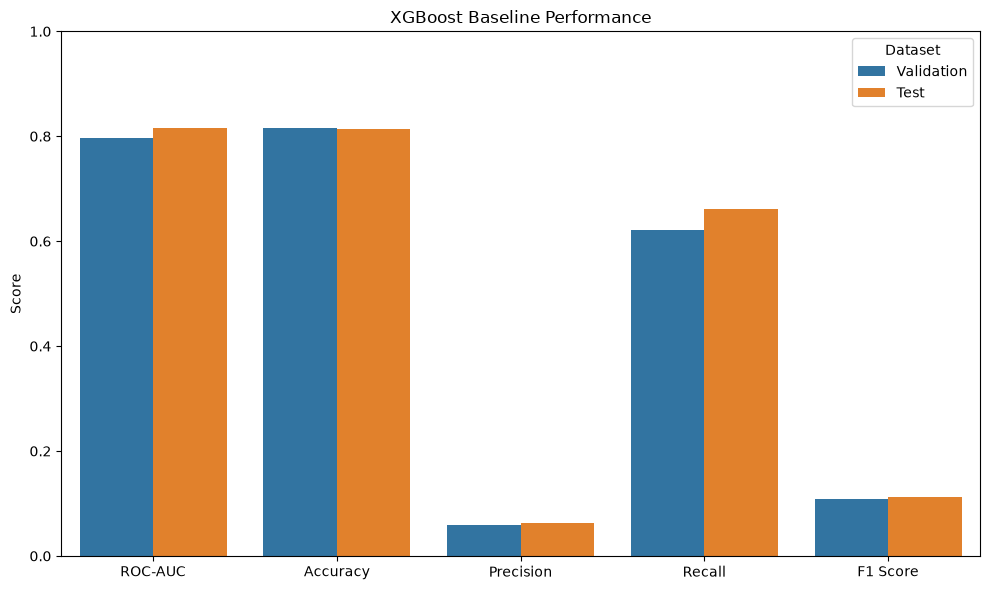

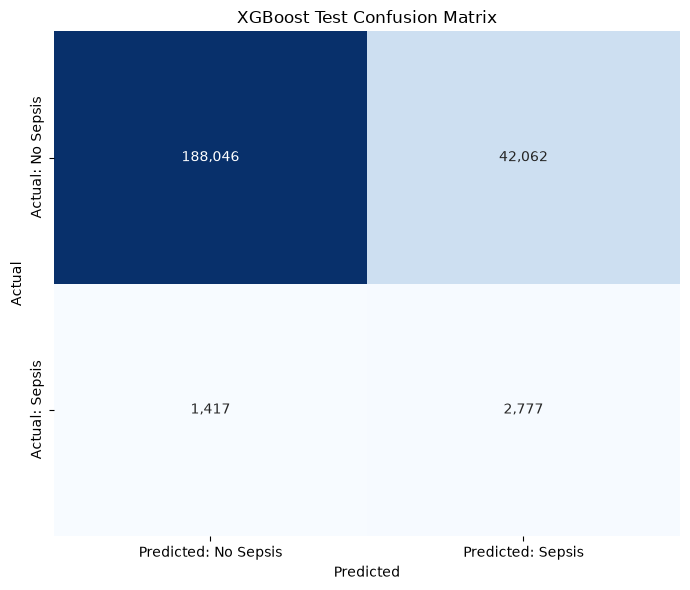


TOP 15 FEATURES BY XGBOOST IMPORTANCE


,Feature,Importance
39,ICULOS,0.1759
10,FiO2,0.0859
7,EtCO2,0.0581
22,Lactate,0.0451
38,HospAdmTime,0.0424
0,HR,0.0412
36,Unit1,0.0397
2,Temp,0.0326
37,Unit2,0.0312
6,Resp,0.0290


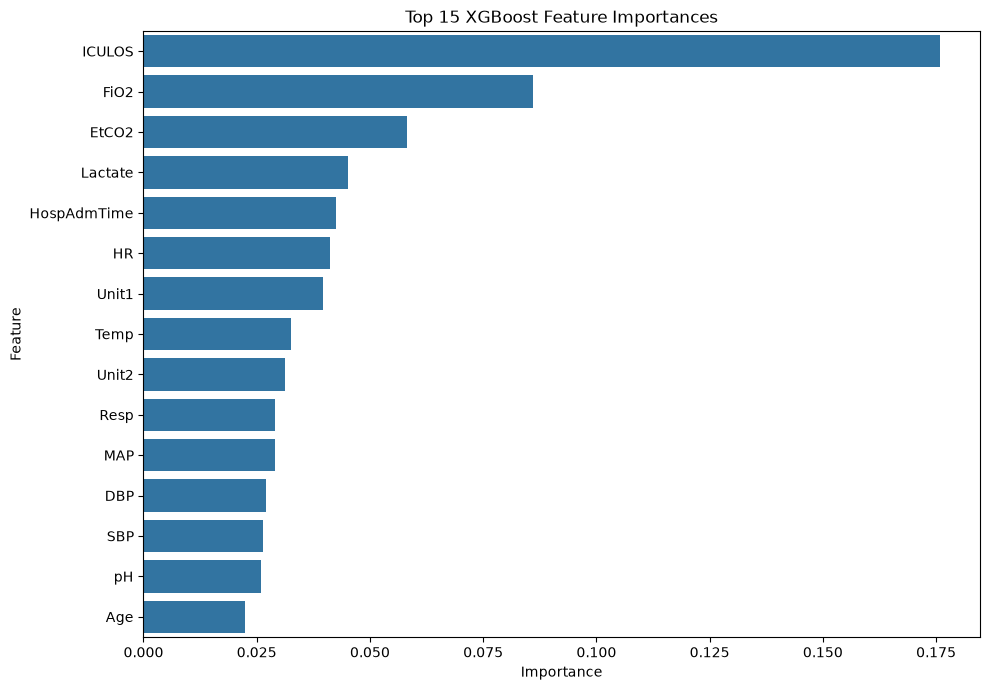

In [17]:
# ============================================================
# XGBoost Baseline — Final Results Dashboard
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ------------------------------------------------------------
# 1. Main performance metrics
# ------------------------------------------------------------

results_df = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Validation": [
        val_auc,
        val_accuracy,
        val_precision,
        val_recall,
        val_f1
    ],
    "Test": [
        test_auc,
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ]
})

print("============================================================")
print("                 XGBOOST BASELINE RESULTS")
print("============================================================")

display(
    results_df.style
    .format({
        "Validation": "{:.4f}",
        "Test": "{:.4f}"
    })
    .set_caption("Validation vs Test Performance")
)

# ------------------------------------------------------------
# 2. Confusion matrix as a DataFrame
# ------------------------------------------------------------

confusion_df = pd.DataFrame(
    test_cm,
    index=["Actual: No Sepsis", "Actual: Sepsis"],
    columns=["Predicted: No Sepsis", "Predicted: Sepsis"]
)

print("\nTEST CONFUSION MATRIX")

display(confusion_df)

# ------------------------------------------------------------
# 3. Model configuration
# ------------------------------------------------------------

config_df = pd.DataFrame({
    "Configuration": [
        "Number of features",
        "Training patients",
        "Training rows",
        "Validation patients",
        "Validation rows",
        "Test patients",
        "Test rows",
        "Positive training samples",
        "scale_pos_weight",
        "Best iteration",
        "Classification threshold"
    ],
    "Value": [
        len(FEATURE_COLUMNS),
        len(train_ids),
        len(train_df),
        len(val_ids),
        len(val_df),
        len(test_ids),
        len(test_df),
        positive,
        round(scale_pos_weight, 2),
        model.best_iteration,
        0.5
    ]
})

print("\nMODEL CONFIGURATION")

display(config_df)

# ------------------------------------------------------------
# 4. Performance comparison graph
# ------------------------------------------------------------

plot_df = results_df.melt(
    id_vars="Metric",
    var_name="Dataset",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x="Metric",
    y="Score",
    hue="Dataset"
)

plt.ylim(0, 1)
plt.title("XGBoost Baseline Performance")
plt.ylabel("Score")
plt.xlabel("")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Test confusion matrix heatmap
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

sns.heatmap(
    confusion_df,
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False
)

plt.title("XGBoost Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Feature importance
# ------------------------------------------------------------

feature_importance_df = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("\nTOP 15 FEATURES BY XGBOOST IMPORTANCE")

display(
    feature_importance_df.head(15)
    .style
    .format({"Importance": "{:.4f}"})
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()